<a href="https://colab.research.google.com/github/Meenakrishnan-work/Meenakrishnan-work.github.io/blob/main/Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [91]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn import metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    roc_auc_score, roc_curve
)
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report


In [41]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [43]:
df = df.drop(['customerID'], axis = 1)

In [44]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [45]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [46]:
print(df["Churn"].unique())

['No' 'Yes']


In [47]:
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


TotalCharges feature is defined as object/str.
But it should be a numerical field. So before converting we need to check for any null values


In [48]:
df[df["TotalCharges"] == " "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [49]:
print(len(df[df["TotalCharges"] == " "]))

11


There are total 11 spaces in Totalcharges feature. Fill those with 0.0 because the customers just opted for subscription and hence 0.0 is applicable for new subscribers

In [50]:
print(df["TotalCharges"].unique()[:20])   # eyeball unusual values

['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']


In [51]:
print(df[df["TotalCharges"] == " "].shape)  # count exact space matches

(11, 20)


In [52]:
df["TotalCharges"] = df["TotalCharges"].str.strip().replace("", "0.0")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)

In [53]:
print(len(df[df["TotalCharges"] == " "]))

0


In [54]:
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [56]:
# 3. Binary Yes/No and Male/Female columns → 0/1 with map (keeps single column, no dummy explosion)
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map(binary_map)


In [57]:
# 4. Multi-category columns → one-hot encoding
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                   'OnlineBackup', 'DeviceProtection', 'TechSupport',
                   'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)
print(df.dtypes)

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No inter

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

**Insights**
1> Customer column removed as not required for
modelling
2> Missing values taken care
3> Total charges column was defined as object with 11 spaces which was filled with value and converted to float
4> Used one hot encoding for multi category colmun where the values are more than 2 categories
5>Used binay mapping for the True binary colmuns where the values are yes/no or male/female

In [58]:
print(df.describe())

            gender  SeniorCitizen      Partner   Dependents       tenure  \
count  7043.000000    7043.000000  7043.000000  7043.000000  7043.000000   
mean      0.504756       0.162147     0.483033     0.299588    32.371149   
std       0.500013       0.368612     0.499748     0.458110    24.559481   
min       0.000000       0.000000     0.000000     0.000000     0.000000   
25%       0.000000       0.000000     0.000000     0.000000     9.000000   
50%       1.000000       0.000000     0.000000     0.000000    29.000000   
75%       1.000000       0.000000     1.000000     1.000000    55.000000   
max       1.000000       1.000000     1.000000     1.000000    72.000000   

       PhoneService  PaperlessBilling  MonthlyCharges  TotalCharges  \
count   7043.000000       7043.000000     7043.000000   7043.000000   
mean       0.903166          0.592219       64.761692   2279.734304   
std        0.295752          0.491457       30.090047   2266.794470   
min        0.000000          0.

In [59]:
X = df.drop(columns=["Churn"])
y= df["Churn"]

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [61]:
print("X_train count:", X_train.shape)
print("y_train count:", y_train.shape)

print("X_test count:", X_test.shape)
print("y_test count:", y_test.shape)

X_train count: (5634, 30)
y_train count: (5634,)
X_test count: (1409, 30)
y_test count: (1409,)


In [62]:
scaler = StandardScaler()

In [63]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
print("X_train_scaled count:", X_train_scaled.shape)
print(X_train_scaled[:2])
print("X_test_scaled count:", X_test_scaled.shape)

X_train_scaled count: (5634, 30)
[[-1.02516569e+00 -4.37749204e-01 -9.69578591e-01  1.53218588e+00
  -4.65683364e-01  3.29573443e-01 -1.20000722e+00 -4.73723375e-04
  -4.19924521e-01 -3.29573443e-01 -8.60523366e-01 -8.87056733e-01
  -5.24080751e-01 -5.24080751e-01  1.58094240e+00 -5.24080751e-01
  -7.33828011e-01 -5.24080751e-01  1.38479574e+00 -5.24080751e-01
  -6.37762944e-01 -5.24080751e-01 -7.94748183e-01 -5.24080751e-01
   1.25076217e+00  1.91010860e+00 -5.58352808e-01 -5.27655848e-01
  -7.09649831e-01  1.84247002e+00]
 [-1.02516569e+00 -4.37749204e-01 -9.69578591e-01 -6.52662324e-01
   8.85536787e-01  3.29573443e-01  8.33328321e-01  1.07475386e+00
   1.25601669e+00 -3.29573443e-01  1.16208349e+00  1.12732361e+00
  -5.24080751e-01 -5.24080751e-01 -6.32534113e-01 -5.24080751e-01
   1.36271713e+00 -5.24080751e-01 -7.22128160e-01 -5.24080751e-01
  -6.37762944e-01 -5.24080751e-01  1.25826019e+00 -5.24080751e-01
   1.25076217e+00 -5.23530443e-01  1.79098231e+00 -5.27655848e-01
  -7.096

In [65]:
print(y_test.value_counts())

Churn
0    1036
1     373
Name: count, dtype: int64


In [66]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [67]:
raw_coef = pd.Series(model.coef_[0], index=X.columns)
coef = raw_coef.sort_values(ascending=False)
print(coef)

TotalCharges                             0.649427
InternetService_Fiber optic              0.619853
StreamingMovies_Yes                      0.228714
StreamingTV_Yes                          0.179380
MultipleLines_Yes                        0.168199
PaperlessBilling                         0.163829
PaymentMethod_Electronic check           0.150618
SeniorCitizen                            0.058854
MultipleLines_No phone service           0.035633
DeviceProtection_Yes                     0.027786
Partner                                  0.027078
PaymentMethod_Mailed check              -0.014680
gender                                  -0.025516
PhoneService                            -0.035633
PaymentMethod_Credit card (automatic)   -0.037216
OnlineBackup_Yes                        -0.045178
Dependents                              -0.072699
OnlineSecurity_No internet service      -0.075444
OnlineBackup_No internet service        -0.075444
StreamingMovies_No internet service     -0.075444


In [68]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


Below barchart shows class balance (what % of customers churned vs stayed)

<Axes: xlabel='Churn'>

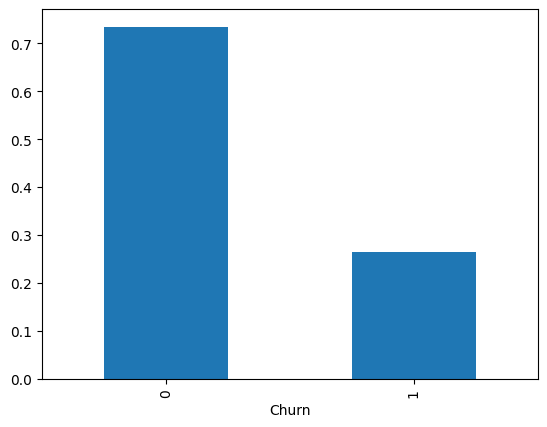

In [69]:
df['Churn'].value_counts(normalize=True).plot(kind='bar')

Histogram plot between tenure split by churn. This plot shows new customers churn more (we already saw this in our coefficients analysis as well)

<Axes: xlabel='tenure', ylabel='Count'>

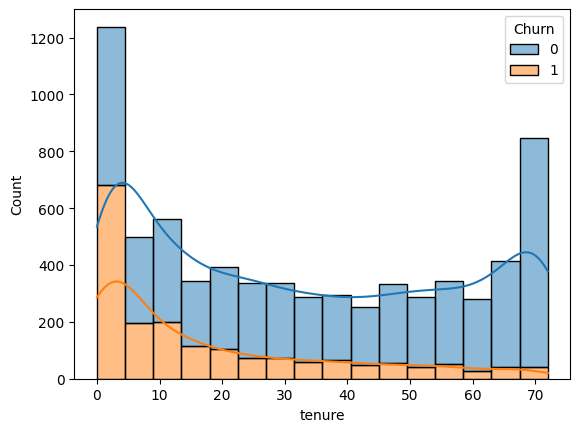

In [70]:
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, multiple='stack')

Boxplot of MonthlyCharges by Churn — shows if higher bills correlate with leaving

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

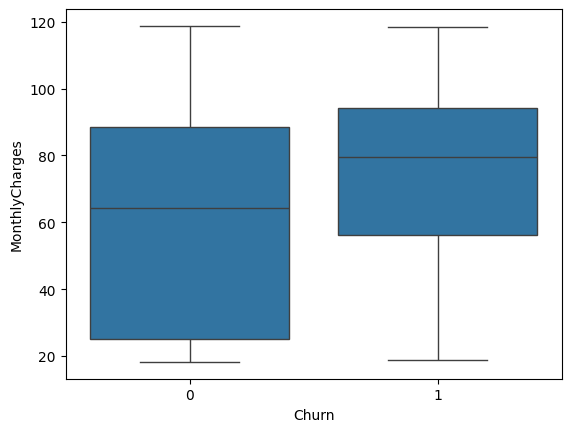

In [71]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

Make model guesses on unseen data

In [77]:
y_pred = model.predict(X_test_scaled)
y_pred

array([1, 0, 0, ..., 0, 0, 0])

**Evaluation**
Core Metrics

Comparing the actaul and predicted result
y_test = the value from test set - this is the data model never seen during training
y_pred = the model's predicted values for those same test rows

In [80]:
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

In [82]:
print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 score        : {f1:.4f}")

Accuracy        : 0.8204
Precision        : 0.6852
Recall        : 0.5952
F1 score        : 0.6370


Confusion Matrix

In [84]:
print(y_test.value_counts())
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Churn
0    1036
1     373
Name: count, dtype: int64
Confusion Matrix:
 [[934 102]
 [151 222]]


In [86]:
print("Classification Report\n")
print(classification_report(y_test, y_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



In [89]:
y_pred_prob = model.predict_proba(X_test)[:, 1]
y_pred_prob

array([0.10530369, 1.        , 1.        , ..., 1.        , 1.        ,
       0.0882531 ])

**MAE** should be well under 0.5 — ideally in the 0.1–0.3 range for a decent churn model


In [92]:
mse = mean_squared_error(y_test, y_pred_prob)
mae = mean_absolute_error(y_test, y_pred_prob)
rmse = np.sqrt(mse)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"MSE             : {mse:.4f}")
print(f"MAE             : {mae:.4f}")
print(f"RMSE            : {rmse:.4f}")
print(f"AUC             : {auc:.4f}")


MSE             : 0.7304
MAE             : 0.7437
RMSE            : 0.8546
AUC             : 0.4137


In [97]:
# Build comparison table
metrics_table = pd.DataFrame({
    "Metric": ["MSE", "MAE", "RMSE", "AUC"],
    "Model Value": [round(mse, 4), round(mae, 4), round(rmse, 4), round(auc, 4)],
    "Excellent": ["< 0.02", "< 0.10", "< 0.15", "> 0.90"],
    "Good": ["0.02 - 0.06", "0.10 - 0.20", "0.15 - 0.25", "0.80 - 0.90"],
    "Acceptable": ["0.06 - 0.15", "0.20 - 0.35", "0.25 - 0.40", "0.70 - 0.80"],
    "Poor": ["> 0.15", "> 0.35", "> 0.40", "< 0.70"]
})


In [96]:
# Status classifier
def get_status(metric, val):
    if metric == "AUC":
        if val > 0.90: return "Excellent"
        elif val > 0.80: return "Good"
        elif val > 0.70: return "Acceptable"
        else: return "Poor"
    thresholds = {
        "MSE":  [(0.02, "Excellent"), (0.06, "Good"), (0.15, "Acceptable")],
        "MAE":  [(0.10, "Excellent"), (0.20, "Good"), (0.35, "Acceptable")],
        "RMSE": [(0.15, "Excellent"), (0.25, "Good"), (0.40, "Acceptable")],
    }
    for limit, label in thresholds[metric]:
        if val < limit:
            return label
    return "Poor"

metrics_table["Status"] = [
    get_status("MSE", mse),
    get_status("MAE", mae),
    get_status("RMSE", rmse),
    get_status("AUC", auc)
]

# Color-code the Status column
def color_status(val):
    colors = {
        "Excellent": "background-color: #b7e4c7",
        "Good": "background-color: #d8f3dc",
        "Acceptable": "background-color: #fff3b0",
        "Poor": "background-color: #ffb3b3"
    }
    return colors.get(val, "")

styled_table = metrics_table.style.applymap(color_status, subset=["Status"])
styled_table

,Metric,Model Value,Excellent,Good,Acceptable,Poor,Status
0,MSE,0.730400,< 0.02,0.02 - 0.06,0.06 - 0.15,> 0.15,Poor
1,MAE,0.743700,< 0.10,0.10 - 0.20,0.20 - 0.35,> 0.35,Poor
2,RMSE,0.854600,< 0.15,0.15 - 0.25,0.25 - 0.40,> 0.40,Poor
3,AUC,0.413700,> 0.90,0.80 - 0.90,0.70 - 0.80,< 0.70,Poor


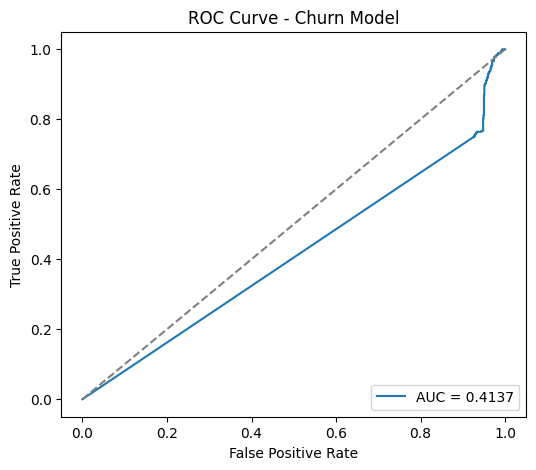

In [93]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Churn Model")
plt.legend(loc="lower right")
plt.show()